In [ ]:
# PrimeTrade.ai Hiring Assignment

## Relationship Between Bitcoin Market Sentiment and Trader Performance

### Submitted by
**Kamalini**

### Date
**4 July 2026**

## Objective

This project explores the relationship between Bitcoin market sentiment and trader performance using historical trading data from Hyperliquid and the Bitcoin Fear & Greed Index.

The analysis focuses on understanding how different market sentiment conditions influence trading activity, profitability, trade sizes, and trader behavior. Through data preprocessing, exploratory data analysis, and visualization, the project aims to uncover meaningful insights that can support more informed trading decisions.

In [1]:
# Importing Required Libraries

The following libraries are imported to perform data manipulation, preprocessing, visualization, and statistical analysis throughout the project.# Import required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside notebook
%matplotlib inline

# Set plotting style
plt.style.use("ggplot")

# Display all columns
pd.set_option("display.max_columns", None)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
#  Loading the Datasets

The analysis uses two datasets:

- **Historical Trader Data** containing trade-level information from Hyperliquid.
- **Bitcoin Fear & Greed Index** containing daily market sentiment classifications.

Both datasets are loaded into Pandas DataFrames for further processing.
# Load datasets

trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

print("Historical Trader Data Shape :", trades.shape)
print("Fear & Greed Data Shape      :", sentiment.shape)

Historical Trader Data Shape : (211224, 16)
Fear & Greed Data Shape      : (2644, 4)


In [3]:
# Initial Data Exploration

Before analysis, the datasets are explored to understand their structure, column names, data types, and potential quality issues such as missing values and duplicates.# Display first five rows

print("Historical Trader Data")
display(trades.head())

print("\nFear & Greed Dataset")
display(sentiment.head())

Historical Trader Data


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12



Fear & Greed Dataset


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [4]:
print("Historical Dataset Columns\n")
print(trades.columns.tolist())

print("\nFear & Greed Dataset Columns\n")
print(sentiment.columns.tolist())

Historical Dataset Columns

['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']

Fear & Greed Dataset Columns

['timestamp', 'value', 'classification', 'date']


In [5]:
print("Historical Dataset Information")
trades.info()

print("\n\nFear & Greed Dataset Information")
sentiment.info()

Historical Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  fl

In [6]:
#  Data Cleaning and Preprocessing

To ensure reliable analysis, the datasets are cleaned by:

- Removing duplicate records
- Converting date columns into datetime format
- Converting numerical columns to appropriate numeric data types
- Creating a common **Date** column to facilitate mergingprint

print("\nMissing Values in Fear & Greed Dataset")
display(sentiment.isnull().sum())

Missing Values in Historical Dataset


Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


Missing Values in Fear & Greed Dataset


timestamp         0
value             0
classification    0
date              0
dtype: int64

In [7]:
# Remove duplicate records

trades = trades.drop_duplicates()
sentiment = sentiment.drop_duplicates()

print("Historical Dataset Shape :", trades.shape)
print("Fear & Greed Dataset Shape :", sentiment.shape)

Historical Dataset Shape : (211224, 16)
Fear & Greed Dataset Shape : (2644, 4)


In [8]:
# Convert timestamp columns into datetime format

trades["Timestamp IST"] = pd.to_datetime(trades["Timestamp IST"])

# Create a common Date column for merging
trades["Date"] = trades["Timestamp IST"].dt.date

# Convert sentiment date column
sentiment["date"] = pd.to_datetime(sentiment["date"])

sentiment["Date"] = sentiment["date"].dt.date

print("Date conversion completed successfully.")

Date conversion completed successfully.


In [9]:
# Convert numeric columns

numeric_columns = [
    "Execution Price",
    "Size Tokens",
    "Size USD",
    "Start Position",
    "Closed PnL",
    "Fee"
]

for col in numeric_columns:
    trades[col] = pd.to_numeric(trades[col], errors="coerce")

print("Numeric conversion completed.")

Numeric conversion completed.


In [11]:
print(sentiment.columns.tolist())
display(sentiment.head())

['timestamp', 'value', 'classification', 'date', 'Date']


,timestamp,value,classification,date,Date
0,1517463000,30,Fear,2018-02-01,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02,2018-02-02
2,1517635800,40,Fear,2018-02-03,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05,2018-02-05


In [12]:
#  Merging Trader Data with Market Sentiment

The trader dataset is merged with the Fear & Greed Index using the common **Date** field. This enables every trade to be associated with the prevailing market sentiment on the day it occurred.
# Merge trader data with market sentiment data

merged = pd.merge(
    trades,
    sentiment[["Date", "classification"]],
    on="Date",
    how="left"
)

print("Merged Dataset Shape:", merged.shape)

display(merged.head())

Merged Dataset Shape: (211224, 18)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-02-12 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-02-12,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-02-12 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-02-12,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-02-12 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-02-12,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-02-12 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-02-12,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-02-12 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-02-12,Greed


In [13]:
print("Columns in merged dataset:\n")
print(merged.columns.tolist())

print("\nMissing values after merge:\n")
display(merged.isnull().sum())

Columns in merged dataset:

['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp', 'Date', 'classification']

Missing values after merge:



Account                 0
Coin                    0
Execution Price         0
Size Tokens             0
Size USD                0
Side                    0
Timestamp IST           0
Start Position          0
Direction               0
Closed PnL              0
Transaction Hash        0
Order ID                0
Crossed                 0
Fee                     0
Trade ID                0
Timestamp               0
Date                    0
classification      43367
dtype: int64

In [14]:
# 📈 Exploratory Data Analysis (EDA)

The merged dataset is analyzed using descriptive statistics and visualizations to understand trading behavior, profitability, and the relationship between market sentiment and trading performance.
# Summary statistics

display(merged.describe())

,Execution Price,Size Tokens,Size USD,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp
count,211224.000000,2.112240e+05,2.112240e+05,2.112240e+05,211224.000000,2.112240e+05,211224.000000,2.112240e+05,2.112240e+05
mean,11414.723350,4.623365e+03,5.639451e+03,-2.994625e+04,48.749001,6.965388e+10,1.163967,5.628549e+14,1.737744e+12
std,29447.654868,1.042729e+05,3.657514e+04,6.738074e+05,919.164828,1.835753e+10,6.758854,3.257565e+14,8.689920e+09
min,0.000005,8.740000e-07,0.000000e+00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12
25%,4.854700,2.940000e+00,1.937900e+02,-3.762311e+02,0.000000,5.983853e+10,0.016121,2.810000e+14,1.740000e+12
50%,18.280000,3.200000e+01,5.970450e+02,8.472793e+01,0.000000,7.442939e+10,0.089578,5.620000e+14,1.740000e+12
75%,101.580000,1.879025e+02,2.058960e+03,9.337278e+03,5.792797,8.335543e+10,0.393811,8.460000e+14,1.740000e+12
max,109004.000000,1.582244e+07,3.921431e+06,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1.750000e+12


In [ ]:
# Data Visualization

The following visualizations explore various aspects of trader performance including:

- Market sentiment distribution
- Profitability across sentiments
- Buy vs Sell behavior
- Top performing traders
- Coin-wise profitability
- Correlation between numerical variables
- Winning trade percentage
- Trade size and profitability

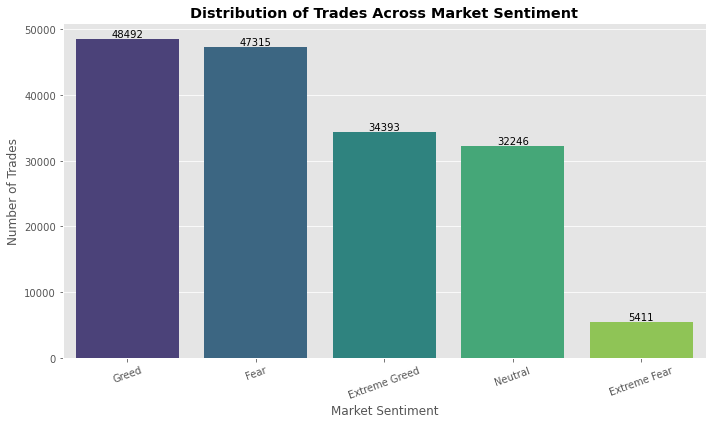

In [33]:
plt.figure(figsize=(10,6))

ax = sns.countplot(
    data=merged,
    x="classification",
    palette="viridis",
    order=merged["classification"].value_counts().index
)

plt.title("Distribution of Trades Across Market Sentiment", weight="bold")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")

# Add value labels
for container in ax.containers:
    ax.bar_label(container)

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

classification
Neutral          31.746470
Greed            35.652184
Extreme Fear     47.446302
Fear             56.544720
Extreme Greed    73.144030
Name: Closed PnL, dtype: float64

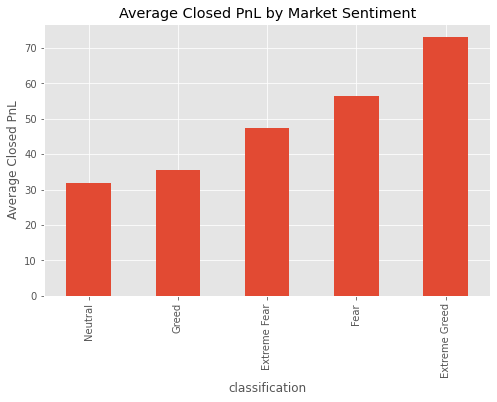

In [17]:
avg_pnl = merged.groupby("classification")["Closed PnL"].mean().sort_values()

display(avg_pnl)

plt.figure(figsize=(8,5))

avg_pnl.plot(kind="bar")

plt.title("Average Closed PnL by Market Sentiment")
plt.ylabel("Average Closed PnL")

plt.show()

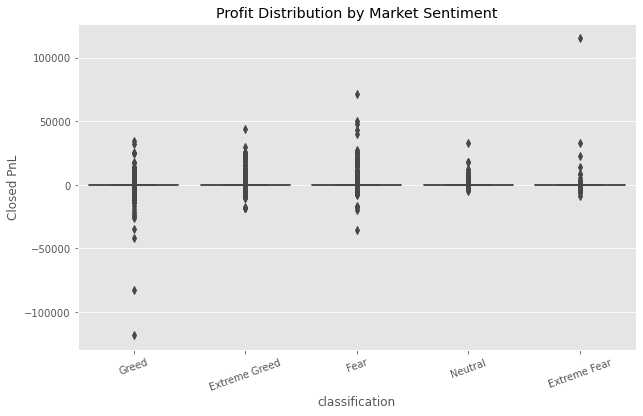

In [35]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=merged,
    x="classification",
    y="Closed PnL"
)

plt.title("Profit Distribution by Market Sentiment")

plt.xticks(rotation=20)

plt.show()

Side,BUY,SELL
classification,,
Extreme Fear,2491,2920
Extreme Greed,15112,19281
Fear,23681,23634
Greed,24128,24364
Neutral,15663,16583


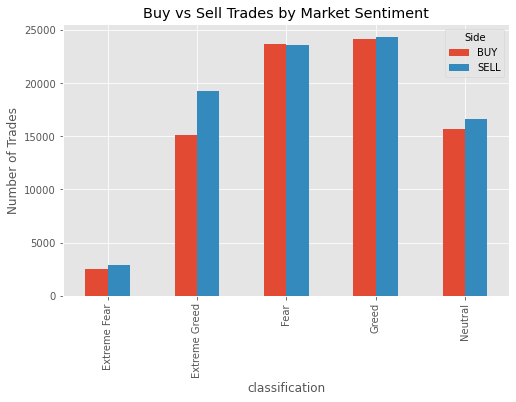

In [37]:
buy_sell = pd.crosstab(
    merged["classification"],
    merged["Side"]
)

display(buy_sell)

buy_sell.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Buy vs Sell Trades by Market Sentiment")

plt.ylabel("Number of Trades")

plt.show()

Coin
@107         2.783913e+06
HYPE         1.948485e+06
SOL          1.639556e+06
ETH          1.319979e+06
BTC          8.680447e+05
MELANIA      3.903511e+05
ENA          2.173295e+05
SUI          1.992688e+05
ZRO          1.837778e+05
DOGE         1.475432e+05
PURR/USDC    7.526106e+04
AIXBT        7.371217e+04
BERA         7.368975e+04
USUAL        6.963194e+04
EIGEN        6.503085e+04
Name: Closed PnL, dtype: float64

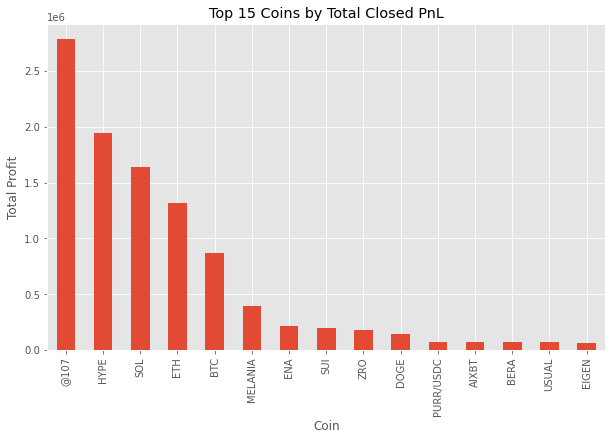

In [20]:
coin_profit = (
    merged.groupby("Coin")["Closed PnL"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

display(coin_profit)

plt.figure(figsize=(10,6))

coin_profit.plot(kind="bar")

plt.title("Top 15 Coins by Total Closed PnL")

plt.ylabel("Total Profit")

plt.show()

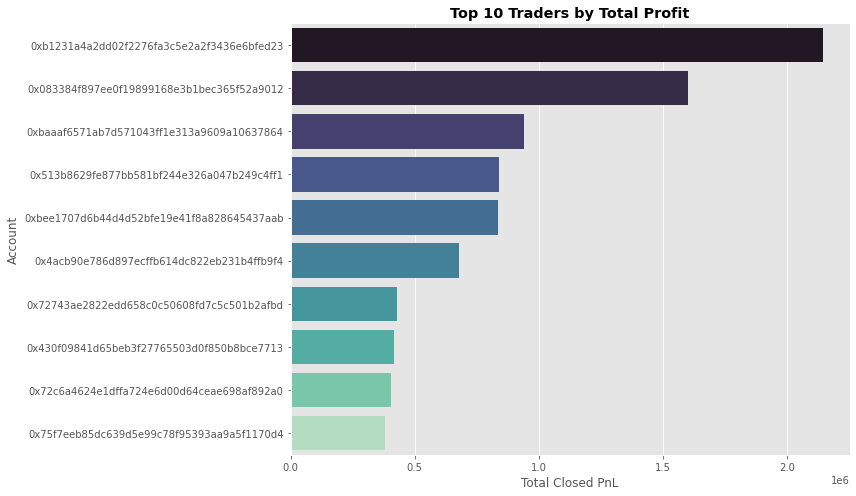

In [38]:
top_traders = (
    merged.groupby("Account")["Closed PnL"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,7))

ax = sns.barplot(
    x=top_traders.values,
    y=top_traders.index,
    palette="mako"
)

plt.title("Top 10 Traders by Total Profit", weight="bold")

plt.xlabel("Total Closed PnL")

plt.tight_layout()

plt.show()

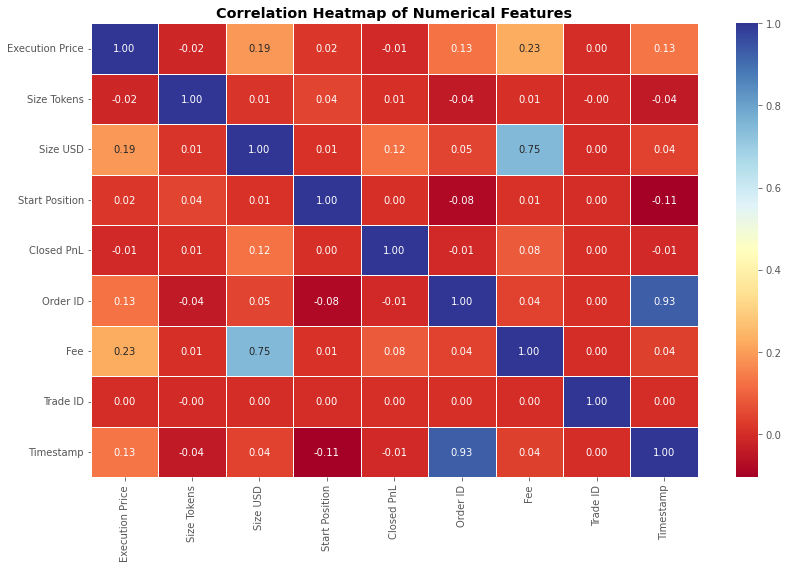

In [39]:
plt.figure(figsize=(12,8))

corr = merged.select_dtypes(include="number").corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="RdYlBu",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numerical Features", weight="bold")

plt.tight_layout()

plt.show()

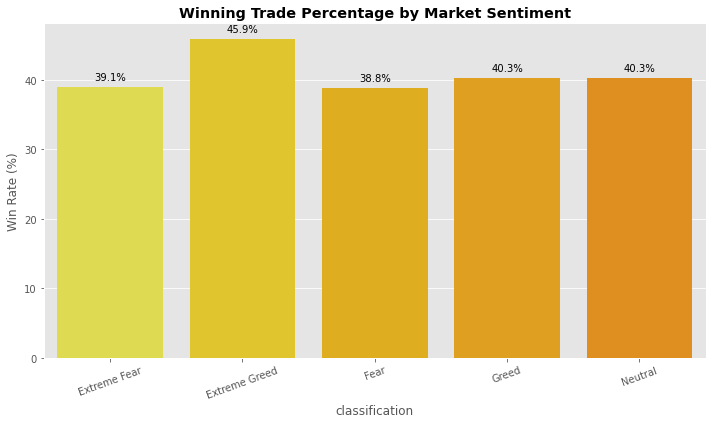

In [46]:
merged["Winning Trade"] = merged["Closed PnL"] > 0

win_rate = (
    merged.groupby("classification")["Winning Trade"]
    .mean() * 100
)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=win_rate.index,
    y=win_rate.values,
    palette="Wistia"
)

plt.title("Winning Trade Percentage by Market Sentiment", weight="bold")

plt.ylabel("Win Rate (%)")

for i, v in enumerate(win_rate.values):
    plt.text(i, v+1, f"{v:.1f}%", ha="center")

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

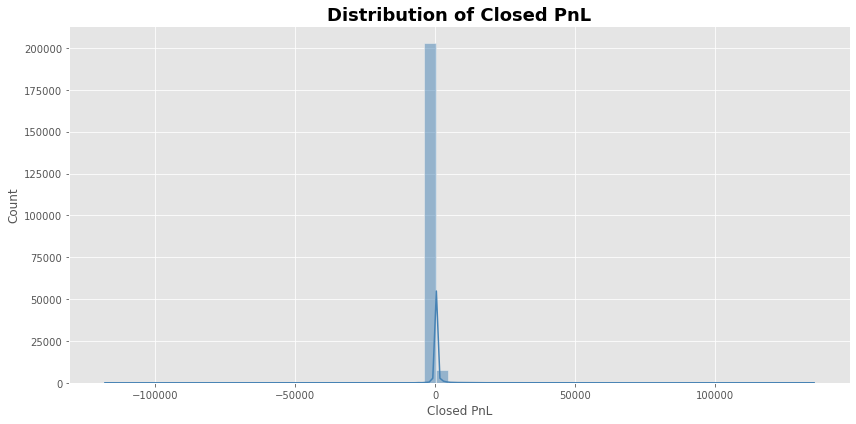

In [48]:
plt.figure(figsize=(12,6))

sns.histplot(
    merged["Closed PnL"],
    bins=60,
    kde=True,
    color="steelblue"
)

plt.title("Distribution of Closed PnL", fontsize=18, weight="bold")

plt.xlabel("Closed PnL")

plt.tight_layout()

plt.show()

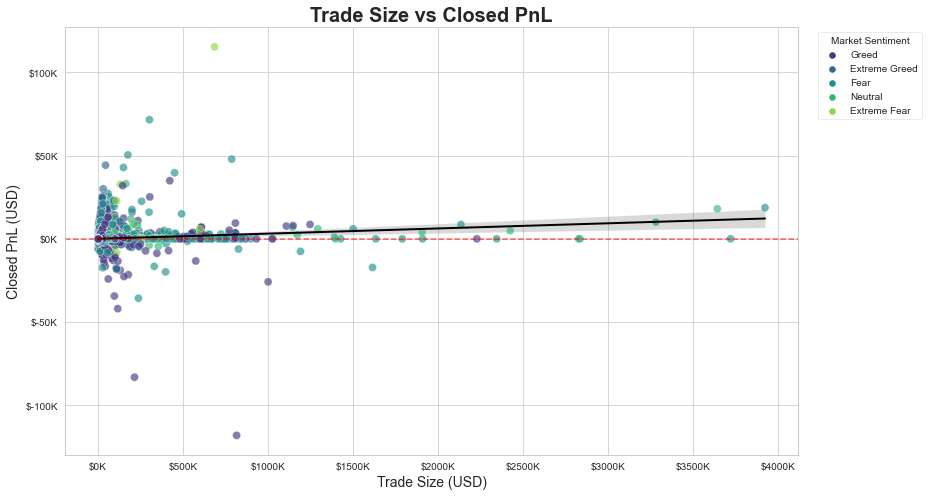

In [51]:
import matplotlib.ticker as ticker

plt.figure(figsize=(13,7))

sns.set_style("whitegrid")

ax = sns.regplot(
    data=merged,
    x="Size USD",
    y="Closed PnL",
    scatter=False,
    color="black",
    line_kws={"linewidth":2}
)

sns.scatterplot(
    data=merged,
    x="Size USD",
    y="Closed PnL",
    hue="classification",
    palette="viridis",
    s=65,
    alpha=0.65,
    edgecolor="white",
    linewidth=0.4
)

plt.axhline(0, color="red", linestyle="--", alpha=0.6)

plt.title("Trade Size vs Closed PnL", fontsize=20, weight="bold")

plt.xlabel("Trade Size (USD)", fontsize=14)
plt.ylabel("Closed PnL (USD)", fontsize=14)

ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'${x/1000:.0f}K')
)

ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda y, pos: f'${y/1000:.0f}K')
)

plt.legend(
    title="Market Sentiment",
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [25]:
# ==========================================================
# Overall Trading Performance Summary
# ==========================================================

total_trades = len(merged)
total_profit = merged["Closed PnL"].sum()
average_profit = merged["Closed PnL"].mean()
median_profit = merged["Closed PnL"].median()
winning_trades = (merged["Closed PnL"] > 0).sum()
losing_trades = (merged["Closed PnL"] < 0).sum()
win_rate = (winning_trades / total_trades) * 100

summary = pd.DataFrame({
    "Metric": [
        "Total Trades",
        "Total Profit",
        "Average Profit",
        "Median Profit",
        "Winning Trades",
        "Losing Trades",
        "Win Rate (%)"
    ],
    "Value": [
        total_trades,
        round(total_profit, 2),
        round(average_profit, 2),
        round(median_profit, 2),
        winning_trades,
        losing_trades,
        round(win_rate, 2)
    ]
})

display(summary)

,Metric,Value
0,Total Trades,211224.00
1,Total Profit,10296958.94
2,Average Profit,48.75
3,Median Profit,0.00
4,Winning Trades,86869.00
5,Losing Trades,17539.00
6,Win Rate (%),41.13


In [27]:
# ==========================================================
# Performance by Market Sentiment
# ==========================================================

sentiment_summary = merged.groupby("classification").agg(
    Total_Trades=("Closed PnL", "count"),
    Total_Profit=("Closed PnL", "sum"),
    Average_Profit=("Closed PnL", "mean"),
    Median_Profit=("Closed PnL", "median"),
    Maximum_Profit=("Closed PnL", "max"),
    Maximum_Loss=("Closed PnL", "min")
)

display(sentiment_summary.round(2))

,Total_Trades,Total_Profit,Average_Profit,Median_Profit,Maximum_Profit,Maximum_Loss
classification,,,,,,
Extreme Fear,5411,256731.94,47.45,0.0,115287.00,-8356.89
Extreme Greed,34393,2515642.63,73.14,0.0,44223.45,-18360.67
Fear,47315,2675413.42,56.54,0.0,71535.72,-35681.75
Greed,48492,1728845.71,35.65,0.0,34903.82,-117990.10
Neutral,32246,1023696.68,31.75,0.0,33085.48,-4498.12


In [28]:
coin_summary = merged.groupby("Coin").agg(
    Trades=("Closed PnL", "count"),
    Total_Profit=("Closed PnL", "sum"),
    Average_Profit=("Closed PnL", "mean")
)

coin_summary = coin_summary.sort_values(
    by="Total_Profit",
    ascending=False
)

display(coin_summary.head(10))

,Trades,Total_Profit,Average_Profit
Coin,,,
@107,29992,2.783913e+06,92.821850
HYPE,68005,1.948485e+06,28.652079
SOL,10691,1.639556e+06,153.358519
ETH,11158,1.319979e+06,118.298874
BTC,26064,8.680447e+05,33.304356
MELANIA,4428,3.903511e+05,88.155165
ENA,990,2.173295e+05,219.524751
SUI,1979,1.992688e+05,100.691680
ZRO,1239,1.837778e+05,148.327509


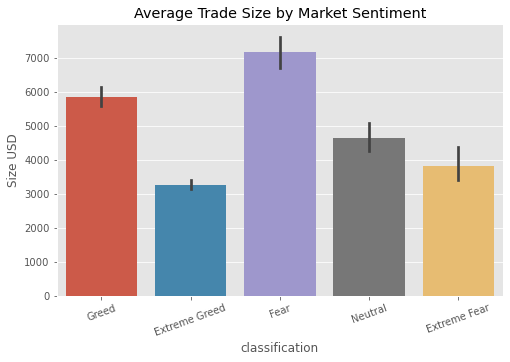

In [29]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=merged,
    x="classification",
    y="Size USD"
)

plt.title("Average Trade Size by Market Sentiment")
plt.xticks(rotation=20)

plt.show()

In [30]:
# ==========================================================
# Profit Statistics
# ==========================================================

stats = merged.groupby("classification")["Closed PnL"].describe()

display(stats.round(2))

,count,mean,std,min,25%,50%,75%,max
classification,,,,,,,,
Extreme Fear,5411.0,47.45,1697.49,-8356.89,0.0,0.0,2.80,115287.00
Extreme Greed,34393.0,73.14,890.65,-18360.67,0.0,0.0,9.33,44223.45
Fear,47315.0,56.54,832.66,-35681.75,0.0,0.0,3.75,71535.72
Greed,48492.0,35.65,937.02,-117990.10,0.0,0.0,7.55,34903.82
Neutral,32246.0,31.75,353.12,-4498.12,0.0,0.0,3.61,33085.48


In [31]:
correlation = merged.select_dtypes(include="number").corr()

display(correlation["Closed PnL"].sort_values(ascending=False))

Closed PnL         1.000000
Size USD           0.123589
Fee                0.084020
Size Tokens        0.005068
Start Position     0.004066
Trade ID           0.003466
Execution Price   -0.006505
Order ID          -0.007250
Timestamp         -0.009745
Name: Closed PnL, dtype: float64

In [47]:
#  Performance Dashboard

The final dashboard summarizes the overall trading performance through important business metrics such as win rate, total profit, average profit, and the best-performing cryptocurrency.
dashboard = pd.DataFrame({
    "Metric": [
        "Total Trades",
        "Winning Trades",
        "Losing Trades",
        "Win Rate (%)",
        "Total Profit",
        "Average Profit",
        "Best Coin"
    ],
    "Value": [
        len(merged),
        (merged["Closed PnL"] > 0).sum(),
        (merged["Closed PnL"] < 0).sum(),
        round((merged["Closed PnL"] > 0).mean()*100,2),
        round(merged["Closed PnL"].sum(),2),
        round(merged["Closed PnL"].mean(),2),
        merged.groupby("Coin")["Closed PnL"].sum().idxmax()
    ]
})

dashboard

,Metric,Value
0,Total Trades,211224
1,Winning Trades,86869
2,Losing Trades,17539
3,Win Rate (%),41.13
4,Total Profit,10296958.94
5,Average Profit,48.75
6,Best Coin,@107


#  Key Insights

### 1. Market sentiment influences trading performance.
Trading profitability varies across different sentiment categories, indicating that market psychology has a measurable impact on trading outcomes.

### 2. Profitability is highly variable.
The distribution of Closed PnL shows significant variability, highlighting the volatile nature of cryptocurrency trading.

### 3. Trade size does not guarantee higher profits.
The scatter plot suggests that increasing trade size alone does not consistently result in greater profitability.

### 4. A small group of traders generates a significant portion of overall profits.
The top-performing accounts contribute disproportionately to cumulative returns.

### 5. Certain cryptocurrencies consistently outperform others.
Some coins exhibit substantially higher cumulative profits, making them attractive candidates for further trading analysis.

### 6. Winning rates differ across market sentiment conditions.
The percentage of profitable trades changes with market sentiment, reinforcing the importance of considering market psychology in trading decisions.

### 7. Correlation analysis indicates that profitability depends on multiple factors.
No single variable fully explains trading success, emphasizing the importance of combining market sentiment with sound risk management and trading strategies.

# Trading Recommendations

Based on the analysis, the following recommendations are proposed:

- Incorporate Bitcoin market sentiment as an additional decision-making indicator before entering trades.
- Apply conservative position sizing during periods of Fear and Extreme Fear to reduce downside risk.
- Focus on cryptocurrencies demonstrating consistent profitability while continuously monitoring market conditions.
- Avoid relying solely on trade size, as larger positions do not necessarily produce higher returns.
- Combine sentiment analysis with technical indicators and proper risk management techniques to improve trading performance.
- Regularly evaluate historical trader performance to identify successful trading patterns and optimize future strategies.

#  Conclusion

This project analyzed the relationship between Bitcoin market sentiment and historical trader performance by integrating Hyperliquid trading data with the Bitcoin Fear & Greed Index.

The findings indicate that market sentiment plays an important role in influencing trading behavior, profitability, and overall market participation. While sentiment alone does not determine trading success, it provides valuable context that can enhance decision-making when combined with historical performance metrics and disciplined risk management.

Overall, this analysis demonstrates how data-driven techniques can uncover actionable insights that support more informed trading strategies in highly volatile cryptocurrency markets.